# Hierarchical Risk Parity vs Mean-Variance vs 1/N

**Question:** Markowitz tells us the optimal portfolio, but only when we know the true covariance matrix. We never do. When the covariance is *estimated*, does a clustering-based allocator (López de Prado's **Hierarchical Risk Parity**) produce better portfolios out-of-sample than minimum-variance optimization or naive 1/N?

This notebook:
1. Builds HRP from scratch: correlation distance → tree clustering → quasi-diagonalization → recursive bisection.
2. Compares it against **1/N**, **inverse-variance (IVP)**, and **long-only minimum-variance** (sample covariance and Ledoit-Wolf shrinkage).
3. Runs a **walk-forward backtest** on a 15-ETF multi-asset universe (2008 onward).
4. Reproduces the **Monte Carlo experiment** from López de Prado (2016) to separate skill from luck.

*Inspired by WQU MScFE 560, Module 3 (Correlation): portfolio variance, diversification, and correlations in stressed markets (Loretan & English, 2000).*

## Background: why estimated covariance breaks Markowitz

For weights $w$ and covariance $\Sigma$, portfolio variance is $\sigma_p^2 = w^\top \Sigma w$. The minimum-variance portfolio is

$$ w^* = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}. $$

It needs $\Sigma^{-1}$. When assets are highly correlated, $\Sigma$ has a large **condition number** (ratio of largest to smallest eigenvalue), so small estimation errors in $\hat\Sigma$ become large errors in $\hat\Sigma^{-1}$ and in the weights. Markowitz's "optimal" portfolio then concentrates in a few assets and rotates between them at every rebalance.

HRP never inverts $\Sigma$. It uses the correlation structure to build a tree and allocates risk top-down between clusters, the way a human portfolio manager would split equities vs bonds first, then within each sleeve.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})
RNG = np.random.default_rng(42)

## 1. Data: a 15-ETF multi-asset universe

The universe spans US and international equity, sectors, Treasuries across the curve, credit, commodities, and real estate, so it has the block correlation structure HRP is designed for. Short Treasuries (SHY, ~1.5% vol) are left out on purpose: a near-cash asset absorbs >90% of every risk-based portfolio and hides the differences between allocators. If `yfinance` is unavailable (offline), we simulate returns from a block factor model with the same shape so every cell still runs.

In [2]:
TICKERS = {
    "SPY": "US large cap", "QQQ": "US tech", "IWM": "US small cap", "EFA": "Intl developed",
    "EEM": "Emerging mkts", "XLE": "Energy", "XLU": "Utilities", "VNQ": "US REITs",
    "IEF": "UST 7-10y", "TLT": "UST 20y+", "LQD": "IG credit",
    "HYG": "HY credit", "GLD": "Gold", "SLV": "Silver", "DBC": "Commodities",
}
START, END = "2008-01-01", "2025-12-31"


def load_prices(tickers, start, end):
    try:
        import yfinance as yf
        px = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=True)["Close"]
        px = px[tickers].dropna()
        if len(px) < 1000:
            raise ValueError("too little data")
        return px, "yfinance"
    except Exception as exc:
        print(f"yfinance unavailable ({exc}); using synthetic data")
        return synthetic_prices(tickers, n=3500), "synthetic"


def synthetic_prices(tickers, n):
    # Block factor model: equity, rates, credit (mix of equity & rates), real assets
    blocks = {"eq": ["SPY", "QQQ", "IWM", "EFA", "EEM", "XLE", "XLU", "VNQ"],
              "rt": ["IEF", "TLT"], "cr": ["LQD", "HYG"], "ra": ["GLD", "SLV", "DBC"]}
    f = RNG.standard_t(df=4, size=(n, 4)) * np.array([0.011, 0.004, 0.003, 0.009]) / np.sqrt(2)
    rets = {}
    for t in tickers:
        if t in blocks["eq"]:
            r = 1.0 * f[:, 0] - 0.2 * f[:, 1] + 0.006 * RNG.standard_normal(n) + 0.0003
        elif t in blocks["rt"]:
            r = (0.3 + 0.7 * blocks["rt"].index(t)) * f[:, 1] + 0.001 * RNG.standard_normal(n) + 0.0001
        elif t in blocks["cr"]:
            r = 0.3 * f[:, 0] + 0.8 * f[:, 1] + f[:, 2] + 0.002 * RNG.standard_normal(n) + 0.0002
        else:
            r = f[:, 3] + 0.1 * f[:, 0] + 0.007 * RNG.standard_normal(n) + 0.0002
        rets[t] = r
    idx = pd.bdate_range("2011-01-03", periods=n)
    return 100 * np.exp(pd.DataFrame(rets, index=idx).cumsum())


prices, SOURCE = load_prices(list(TICKERS), START, END)
returns = np.log(prices).diff().dropna()
print(f"source={SOURCE}  period={returns.index[0].date()} → {returns.index[-1].date()}  obs={len(returns)}")
returns.describe().T[["mean", "std"]].assign(ann_vol=lambda d: d["std"] * np.sqrt(252)).round(4)

source=yfinance  period=2008-01-03 → 2025-12-30  obs=4527


,mean,std,ann_vol
Ticker,,,
SPY,0.0004,0.0126,0.1997
QQQ,0.0006,0.0142,0.2248
IWM,0.0003,0.0158,0.2507
EFA,0.0002,0.0138,0.2194
EEM,0.0001,0.0174,0.2763
XLE,0.0002,0.0194,0.3079
XLU,0.0003,0.0121,0.1925
VNQ,0.0002,0.0189,0.3004
IEF,0.0001,0.0044,0.0703


## 2. Correlation distance and tree clustering

López de Prado maps correlation to a proper distance metric:

$$ d_{ij} = \sqrt{\tfrac{1}{2}(1-\rho_{ij})} \in [0, 1] $$

Perfectly correlated assets are at distance 0, perfectly anti-correlated at distance 1. We then run agglomerative (single-linkage) clustering on these distances. The resulting dendrogram shows which assets behave as one "economic bet".

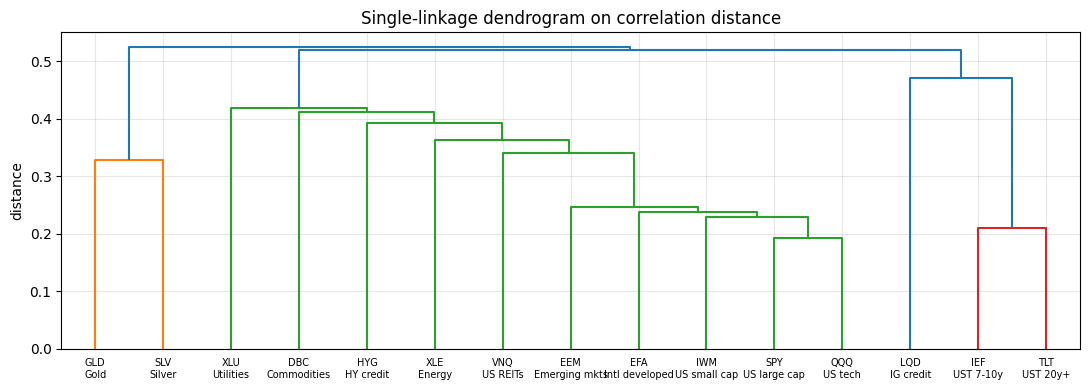

In [3]:
def correl_dist(corr):
    return np.sqrt(np.clip((1 - corr) / 2.0, 0.0, None))


corr = returns.corr()
dist = correl_dist(corr)
link = sch.linkage(squareform(dist.values, checks=False), method="single")

fig, ax = plt.subplots(figsize=(11, 4))
sch.dendrogram(link, labels=[f"{t}\n{TICKERS[t]}" for t in corr.columns], ax=ax, leaf_font_size=7, color_threshold=0.45)
ax.set_title("Single-linkage dendrogram on correlation distance")
ax.set_ylabel("distance")
plt.tight_layout(); plt.show()

## 3. Quasi-diagonalization

Reordering rows and columns in dendrogram-leaf order moves large covariances next to the diagonal. Nothing about the matrix changes except the order, but the block structure becomes visible and the recursive bisection step can split the portfolio into contiguous, similar groups.

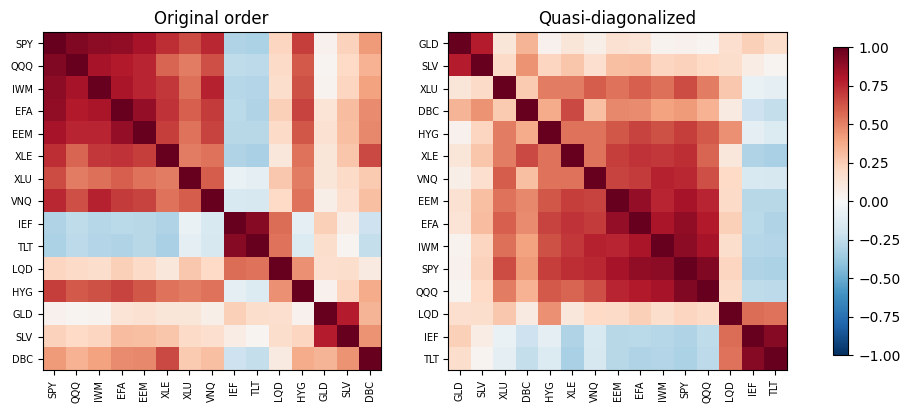

Leaf order: ['GLD', 'SLV', 'XLU', 'DBC', 'HYG', 'XLE', 'VNQ', 'EEM', 'EFA', 'IWM', 'SPY', 'QQQ', 'LQD', 'IEF', 'TLT']


In [4]:
def quasi_diag(link):
    # Leaf order of the dendrogram (equivalent to López de Prado's getQuasiDiag)
    return sch.leaves_list(link).tolist()


order = quasi_diag(link)
sorted_tickers = corr.columns[order].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, c, title in [(axes[0], corr, "Original order"),
                     (axes[1], corr.loc[sorted_tickers, sorted_tickers], "Quasi-diagonalized")]:
    im = ax.imshow(c.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(c))); ax.set_xticklabels(c.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(c))); ax.set_yticklabels(c.index, fontsize=7)
    ax.set_title(title); ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()
print("Leaf order:", sorted_tickers)

## 4. Recursive bisection

Starting with all assets in one cluster (in quasi-diagonal order):

1. Split the list into two halves $L_1, L_2$.
2. For each half, compute the variance $V_i = \tilde w_i^\top \Sigma_i \tilde w_i$ of its **inverse-variance** sub-portfolio $\tilde w_i \propto 1/\mathrm{diag}(\Sigma_i)$.
3. Allocate $\alpha = 1 - V_1/(V_1+V_2)$ to $L_1$ and $1-\alpha$ to $L_2$, so the riskier half gets less.
4. Recurse until each cluster holds one asset.

Weights are positive and sum to 1 by construction, and no matrix is ever inverted.

In [5]:
def ivp(cov):
    iv = 1.0 / np.diag(cov)
    return iv / iv.sum()


def cluster_var(cov, items):
    sub = cov[np.ix_(items, items)]
    w = ivp(sub)
    return float(w @ sub @ w)


def hrp_weights(cov, linkage_method="single"):
    # HRP allocation for a covariance matrix (np.ndarray). Returns weights in original asset order.
    cov = np.asarray(cov)
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    link = sch.linkage(squareform(correl_dist(corr), checks=False), method=linkage_method)
    order = sch.leaves_list(link).tolist()

    w = np.ones(len(cov))
    clusters = [order]
    while clusters:
        clusters = [c[j:k] for c in clusters for j, k in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            left, right = clusters[i], clusters[i + 1]
            v_l, v_r = cluster_var(cov, left), cluster_var(cov, right)
            alpha = 1 - v_l / (v_l + v_r)
            w[left] *= alpha
            w[right] *= 1 - alpha
    return w


cov_full = returns.cov().values * 252
w_hrp = pd.Series(hrp_weights(cov_full), index=returns.columns)
print(f"sum of weights = {w_hrp.sum():.6f}")
w_hrp.sort_values(ascending=False).round(4)

sum of weights = 1.000000


Ticker
IEF    0.2942
LQD    0.2676
HYG    0.0983
TLT    0.0611
GLD    0.0545
QQQ    0.0429
XLU    0.0384
DBC    0.0323
SPY    0.0247
EFA    0.0206
IWM    0.0157
SLV    0.0144
EEM    0.0130
VNQ    0.0114
XLE    0.0109
dtype: float64

## 5. Benchmark allocators

| Portfolio | Uses | Weakness |
|---|---|---|
| **1/N** | nothing | ignores risk; equity-heavy universes get equity-heavy risk |
| **IVP** | variances only | ignores correlation |
| **MinVar (sample)** | full $\hat\Sigma$, long-only | error-maximizing, concentrated |
| **MinVar (Ledoit-Wolf)** | shrunk $\hat\Sigma$, long-only | the stronger, fairer Markowitz benchmark |
| **HRP** | correlation tree + variances | no explicit optimality |

Long-only minimum variance is solved numerically with SLSQP.

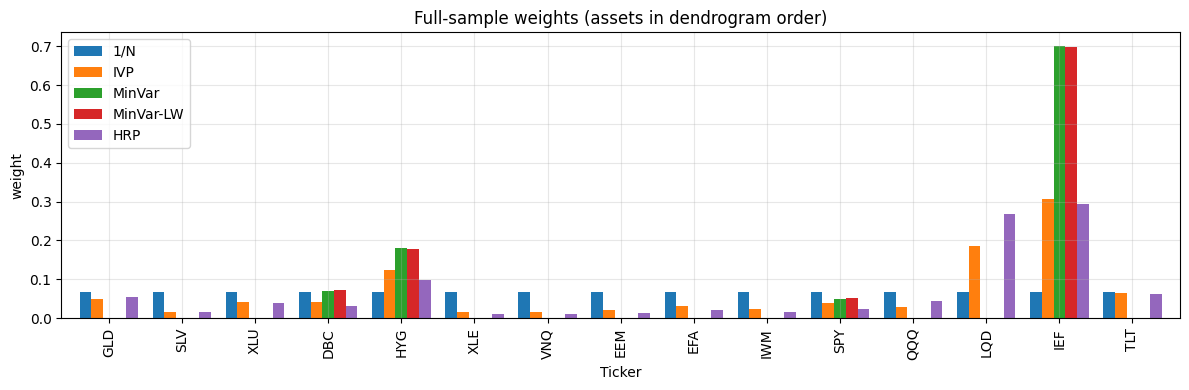

Condition number of sample covariance: 623
Effective number of holdings (1/sum w²):
1/N          15.0
IVP           6.3
MinVar        1.9
MinVar-LW     1.9
HRP           5.5


In [6]:
def equal_weight(cov):
    n = len(cov)
    return np.full(n, 1.0 / n)


def min_var(cov):
    n = len(cov)
    res = minimize(lambda w: w @ cov @ w, np.full(n, 1.0 / n), jac=lambda w: 2 * cov @ w,
                   bounds=[(0, 1)] * n, constraints=({"type": "eq", "fun": lambda w: w.sum() - 1},),
                   method="SLSQP", options={"ftol": 1e-12, "maxiter": 500})
    w = np.clip(res.x, 0, None)
    return w / w.sum()


def lw_cov(rets):
    return LedoitWolf().fit(rets).covariance_


ALLOCATORS = {
    "1/N": lambda r: equal_weight(np.cov(r, rowvar=False)),
    "IVP": lambda r: ivp(np.cov(r, rowvar=False)),
    "MinVar": lambda r: min_var(np.cov(r, rowvar=False)),
    "MinVar-LW": lambda r: min_var(lw_cov(r)),
    "HRP": lambda r: hrp_weights(np.cov(r, rowvar=False)),
}

full = returns.values
weights_full = pd.DataFrame({k: f(full) for k, f in ALLOCATORS.items()}, index=returns.columns)

fig, ax = plt.subplots(figsize=(12, 4))
weights_full.loc[sorted_tickers].plot.bar(ax=ax, width=0.8)
ax.set_title("Full-sample weights (assets in dendrogram order)"); ax.set_ylabel("weight")
plt.tight_layout(); plt.show()

eig = np.linalg.eigvalsh(np.cov(full, rowvar=False))
print(f"Condition number of sample covariance: {eig.max() / eig.min():,.0f}")
print("Effective number of holdings (1/sum w²):")
print((1 / (weights_full ** 2).sum()).round(1).to_string())

**Reading the chart:** long-only minimum variance puts ~70% in IEF and most of the rest in HYG and DBC. It picks those because they hedge each other in-sample, and gives zero weight to 10 of 15 assets (effective holdings ≈ 1.9). HRP also leans toward bonds (IEF + LQD ≈ 56%) but keeps every asset, and its weights follow the dendrogram: the equity cluster gets a share, then that share is split inside the cluster.

## 6. Walk-forward backtest

Every 21 trading days each allocator sees only the **previous 252 days**, sets weights, and holds them until the next rebalance. We track out-of-sample daily returns, turnover, and the volatility of each portfolio.

In [7]:
LOOKBACK, REBAL, COST_BPS = 252, 21, 5  # 5 bps one-way transaction cost


def walk_forward(rets, allocators, lookback=LOOKBACK, rebal=REBAL, cost_bps=COST_BPS):
    simple = np.expm1(rets)
    dates = rets.index
    out = {k: pd.Series(0.0, index=dates[lookback:]) for k in allocators}
    turnover = {k: [] for k in allocators}
    prev_w = {k: np.zeros(rets.shape[1]) for k in allocators}
    for start in range(lookback, len(rets), rebal):
        window = rets.values[start - lookback:start]
        hold = simple.iloc[start:start + rebal]
        for name, alloc in allocators.items():
            w = alloc(window)
            to = np.abs(w - prev_w[name]).sum()
            turnover[name].append(to)
            # buy-and-hold inside the period: weights drift with prices
            growth = (1 + hold).cumprod()
            value = growth.values @ w
            daily = np.diff(np.concatenate([[1.0], value])) / np.concatenate([[1.0], value[:-1]])
            daily[0] -= to * cost_bps / 1e4
            out[name].loc[hold.index] = daily
            prev_w[name] = (growth.values[-1] * w) / value[-1]
    return pd.DataFrame(out), {k: np.mean(v) for k, v in turnover.items()}


oos, avg_turnover = walk_forward(returns, ALLOCATORS)


def perf_table(r, turnover=None):
    ann_ret = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    t = pd.DataFrame({"ann_return": ann_ret, "ann_vol": ann_vol, "sharpe": ann_ret / ann_vol,
                      "max_drawdown": mdd, "calmar": ann_ret / -mdd})
    if turnover:
        t["avg_turnover"] = pd.Series(turnover)
    return t


perf_table(oos, avg_turnover).round(3)

,ann_return,ann_vol,sharpe,max_drawdown,calmar,avg_turnover
1/N,0.094,0.120,0.787,-0.255,0.369,0.035
IVP,0.053,0.068,0.781,-0.192,0.278,0.061
MinVar,0.031,0.052,0.583,-0.174,0.176,0.123
MinVar-LW,0.036,0.055,0.660,-0.165,0.220,0.110
HRP,0.045,0.067,0.670,-0.192,0.232,0.137


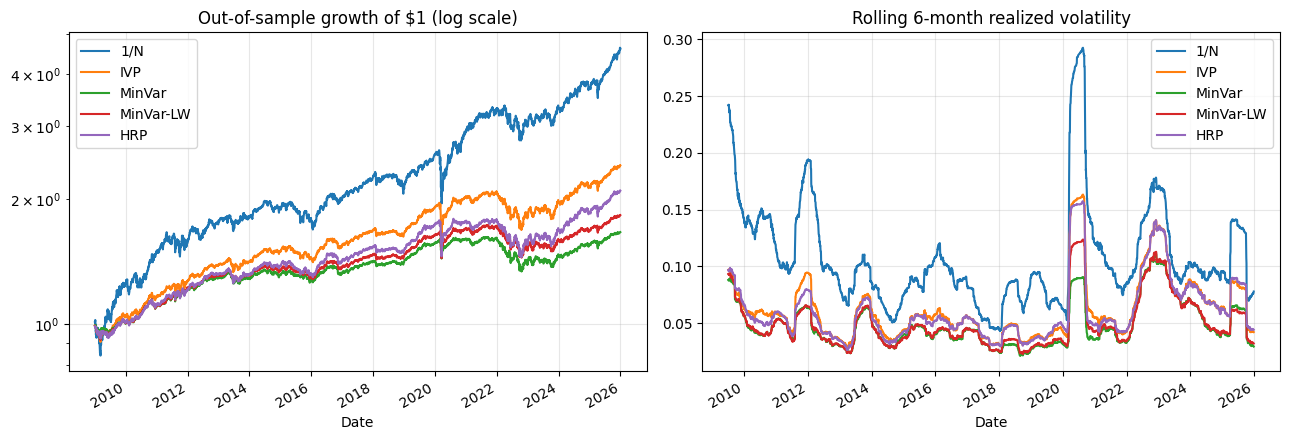

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
(1 + oos).cumprod().plot(ax=axes[0], logy=True)
axes[0].set_title("Out-of-sample growth of $1 (log scale)")
(oos.rolling(126).std() * np.sqrt(252)).plot(ax=axes[1])
axes[1].set_title("Rolling 6-month realized volatility")
plt.tight_layout(); plt.show()

### Stress periods

Loretan & English (2000) warn that correlations measured in calm markets understate co-movement in crises. So we check how each allocator did in the stress windows that fall inside the sample.

In [9]:
STRESS = {"GFC 2008-09": ("2008-09-01", "2009-03-31"), "Euro crisis 2011": ("2011-07-01", "2011-10-31"),
          "COVID crash 2020": ("2020-02-15", "2020-04-30"), "Rates shock 2022": ("2022-01-01", "2022-10-31")}
rows = {}
for label, (a, b) in STRESS.items():
    seg = oos.loc[a:b]
    if len(seg) > 20:
        rows[label] = (1 + seg).prod() - 1
stress = pd.DataFrame(rows).T
stress.style.format("{:.1%}") if len(stress) else "No stress windows inside the sample period"

,1/N,IVP,MinVar,MinVar-LW,HRP
GFC 2008-09,-7.3%,-4.8%,-2.5%,-4.4%,-4.1%
Euro crisis 2011,0.9%,3.4%,3.8%,4.4%,3.6%
COVID crash 2020,-10.8%,-6.5%,-3.3%,-4.1%,-7.0%
Rates shock 2022,-12.6%,-16.9%,-15.7%,-14.8%,-16.7%


## 7. Monte Carlo: is the difference skill or luck?

One historical path is one draw. López de Prado's experiment simulates many paths where the true structure is known: 10 assets, 5 of which are noisy copies of the others (hidden clusters), plus random common and idiosyncratic shocks. Each path is backtested with the same rolling procedure, and we compare the **out-of-sample variance** of each allocator across paths.

We use 200 paths here (the paper uses 10,000). Raise `N_PATHS` for tighter estimates.

In [10]:
def generate_data(n_obs=520, size0=5, size1=5, sigma1=0.25, rng=RNG):
    # López de Prado (2016) data-generating process
    x = rng.normal(0, 1, size=(n_obs, size0))
    cols = rng.integers(0, size0, size=size1)
    y = x[:, cols] + rng.normal(0, sigma1, size=(n_obs, size1))
    x = np.hstack([x, y])
    # common shock and idiosyncratic shock
    point = rng.integers(260, n_obs, size=2)
    x[point[0], [cols[0], size0]] = [-0.5, -0.5]
    point = rng.integers(260, n_obs, size=2)
    x[point[0], cols[-1]] = 2.0
    return x / 100  # percent-scale daily returns


N_PATHS, LB, RB = 200, 260, 22
mc_alloc = {k: v for k, v in ALLOCATORS.items()}
oos_var = {k: [] for k in mc_alloc}
for _ in range(N_PATHS):
    x = generate_data()
    pnl = {k: [] for k in mc_alloc}
    for s in range(LB, x.shape[0], RB):
        win, fwd = x[s - LB:s], x[s:s + RB]
        for k, f in mc_alloc.items():
            pnl[k].extend(fwd @ f(win))
    for k in mc_alloc:
        oos_var[k].append(np.var(pnl[k]))

mc = pd.DataFrame(oos_var)
summary = pd.DataFrame({"mean_oos_variance": mc.mean(), "std_across_paths": mc.std()})
summary["vs_HRP"] = summary["mean_oos_variance"] / summary.loc["HRP", "mean_oos_variance"] - 1
summary.sort_values("mean_oos_variance").style.format({"mean_oos_variance": "{:.3e}", "std_across_paths": "{:.3e}", "vs_HRP": "{:+.1%}"})

,mean_oos_variance,std_across_paths,vs_HRP
MinVar-LW,2.017e-05,1.935e-06,-6.8%
MinVar,2.020e-05,1.945e-06,-6.6%
HRP,2.163e-05,2.176e-06,+0.0%
IVP,2.390e-05,3.363e-06,+10.5%
1/N,2.396e-05,3.361e-06,+10.8%


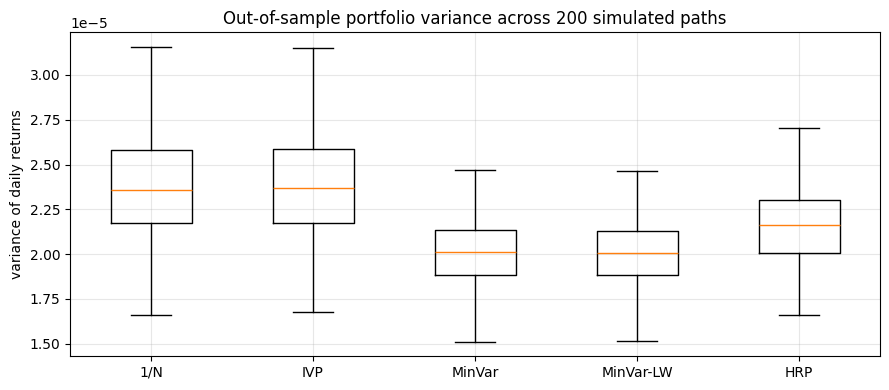

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([mc[k] for k in mc.columns], labels=mc.columns, showfliers=False)
ax.set_title(f"Out-of-sample portfolio variance across {N_PATHS} simulated paths")
ax.set_ylabel("variance of daily returns")
plt.tight_layout(); plt.show()

## 8. Takeaways

The numbers below come from the run with yfinance data through 2025 and 200 Monte Carlo paths; they will shift a little with new data.

- **Minimum variance still wins on its own objective.** In the Monte Carlo, long-only MinVar had about 7% *lower* out-of-sample variance than HRP. That is the opposite of the paper's headline result. The paper's CLA benchmark is a different optimizer, and the long-only constraint already regularizes minimum variance a lot. HRP did beat 1/N and IVP by about 10%.
- **HRP is the most diversified risk-based portfolio.** It keeps about 5.5 effective holdings against about 1.9 for MinVar, with a volatility between IVP and MinVar.
- **But HRP is not the most stable.** In the walk-forward backtest HRP had the *highest* average turnover. Single-linkage trees are sensitive, so when one correlation moves an asset can jump branches and the bisection reshuffles weights. Ward or average linkage, or smoothing the correlation estimate, are the usual fixes.
- **No allocator is crisis-proof.** Risk-based portfolios cut the GFC and COVID drawdowns roughly in half compared with 1/N. In 2022, when stocks and bonds fell together, they lost *more* than 1/N (about −15% to −17% vs −12.6%) because they were concentrated in duration. That is the correlation breakdown Loretan & English describe.
- **Risk-adjusted return:** 1/N had the best Sharpe ratio (~0.79, tied with IVP), consistent with DeMiguel et al. (2009) and recent HRP studies (e.g. *Hierarchical risk parity: Efficient implementation and real world analysis*, 2025).

**Extensions:** compare linkage methods (ward, average) on turnover, run HRP on a Ledoit-Wolf covariance, break down risk contribution by cluster, and put the backtest's winner through the Deflated Sharpe Ratio (see `../BacktestOverfitting`).